# Test ABL with K-epsilon model

In [1]:
# Add any possible locations of amr-wind-frontend here
import sys, os
curdir = os.getcwd()
extradirs = ['../', './',
             os.path.dirname(curdir),
            ]
for x in extradirs: sys.path.insert(1, x)

import numpy as np
import matplotlib.pyplot as plt
import SANDwake3D_base as sdb
import SANDwake3D_keps as SANDwake3D

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import time
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
from mpl_toolkits.axes_grid1 import make_axes_locatable
#?solve_ivp

## Set mesh and BC's 

In [3]:
# Set up mesh and BL parameters
nu   = 1.5E-5 # m^2/s

# y-z mesh
dz   = 5
zmin = dz
zmax = 500
Nz   = int((zmax-zmin)/dz+1)
zvec = np.linspace(zmin,zmax,Nz)

Ny   = 101
ymax = 250
yvec = np.linspace(-ymax,ymax,Ny)


In [4]:
ym, zm = np.meshgrid(yvec, zvec, indexing='ij')

dy   = np.mean(np.diff(yvec))
dz   = np.mean(np.diff(zvec))
print(f'dy = {dy}')
print(f'dz = {dz}')
print(ym.shape)

dy = 5.0
dz = 5.0
(101, 100)


In [5]:
# Set parameters
params = {
    'rho' : 1.225,
    'cp'  : 1005,
    'g'   : 9.81,
    'nu'  : nu,
    'Cmu' : 5.48**(-2),
    'C1eps' : 1.76,
    'C2eps' : 1.92,
    'C3eps' : 0.033,
    'sigmak' : 1.0,
    'sigmaeps' : 1.3,
    'sigmaT':1.0,
    'dtau':1.0,
    
    'ustar' : 0.47, #0.4, #0.575652,
    'qw': 0.0,
    'L' : float('inf'),
    'kappa' : 0.42,
    'z0' : 0.05,
    'beta':1.0/300.0,

    'zlo':zmin,
    'Tw':300,
    
    # Extra mesh variables needed for turbine forcing
    'ym':ym,
    'zm':zm,
    'turbforcing':{'name':'Turb0',  # name (optional for now)
                   'turbx':0.0,     # Turbine x location
                   'turby':0.0,     # Turbine y location
                   'zhh':150.0,     # Turbine hub-height
                   'turbD':240.0,   # Turbine diameter
                   'Rdelta':0.5,
                   'turbfunc':sdb.tanhADM,
                   'CtCpSource':'FlorisFile',
                   'turbinefilename':'iea_15MW.yaml', # file containing wind speed / Ct table
                   'Ct':[0.8, 0.8],
                   'WS':[0, 1000],
                  }
}

# This parameter defines V(z) -- m/s per meter
veerpermeter = 0.0 #0.02

In [6]:
# Set up ABL profile
UABL = np.zeros(Nz)
for iz, z in enumerate(zvec):
    UABL[iz] = SANDwake3D.init_U_ABL(z,params)
    
# Set up veer profile
turbhh = params['turbforcing']['zhh']
turbR  = params['turbforcing']['turbD']*0.5
veerV = np.zeros(Nz)
for i, z in enumerate(zvec):
    veerV[i] = veerpermeter*(z-turbhh)
    
# Compute the wind direction
ztop = turbhh + turbR
zbot = turbhh - turbR
Utop, Ubot = np.interp(ztop, zvec, UABL), np.interp(zbot, zvec, UABL)
Vtop, Vbot = np.interp(ztop, zvec, veerV), np.interp(zbot, zvec, veerV)
Wdirtop = np.arctan2(Vtop, Utop)*180/np.pi
Wdirbot = np.arctan2(Vbot, Ubot)*180/np.pi

Uhh, Vhh = np.interp(turbhh, zvec, UABL), np.interp(turbhh, zvec, UABL)
alpha = np.log(Utop/Ubot)/np.log(ztop/zbot)
print('Uhh = ',Uhh)
print('alpha = ',alpha)
print('rotor veer = ',Wdirtop-Wdirbot)

Uhh =  8.959506563799085
alpha =  0.13438048203877503
rotor veer =  0.0


In [7]:
Uinit  = np.zeros((Ny, Nz))
Vinit  = np.zeros((Ny, Nz))
Winit  = np.zeros((Ny, Nz))
Kinit  = np.zeros((Ny, Nz))
Tinit  = np.ones((Ny, Nz))*300
EPSinit= np.zeros((Ny, Nz))
pinit  = np.zeros((Ny, Nz))

for iz, z in enumerate(zvec):
    Uinit[:, iz] = UABL[iz] #SANDwake3D.init_U_ABL(z,ABLparam)
    Vinit[:, iz] = veerV[iz]
    Winit[:, iz] = 0.0
    #Kinit[:, iz]   = SANDwake3D.init_k_ABL(z,ABLparam) #*0.5 #0.2
    Kinit[:, iz]   = SANDwake3D.init_k_ABL(z,params)*1.0 #*0.75
    #EPSinit[:, iz] = 5.0E-3 #9.75E-4 #5.0E-4 #SANDwake3D.init_e_ABL(z,ABLparam)*0.1  #5.0E-4 is good
    EPSinit[:, iz] = SANDwake3D.init_e_ABL(z,params)
    #EPSinit[:, iz] = SANDwake3D.init_e_ABL(z,ABLparam)*0.50  #5.0E-4 is good

phiinit = {}
phiinit['u'] = Uinit
phiinit['v'] = Vinit
phiinit['w'] = Winit
phiinit['k'] = Kinit
phiinit['T'] = Tinit
phiinit['eps'] = EPSinit
phiinit['p'] = pinit

(0.0, 500.0)

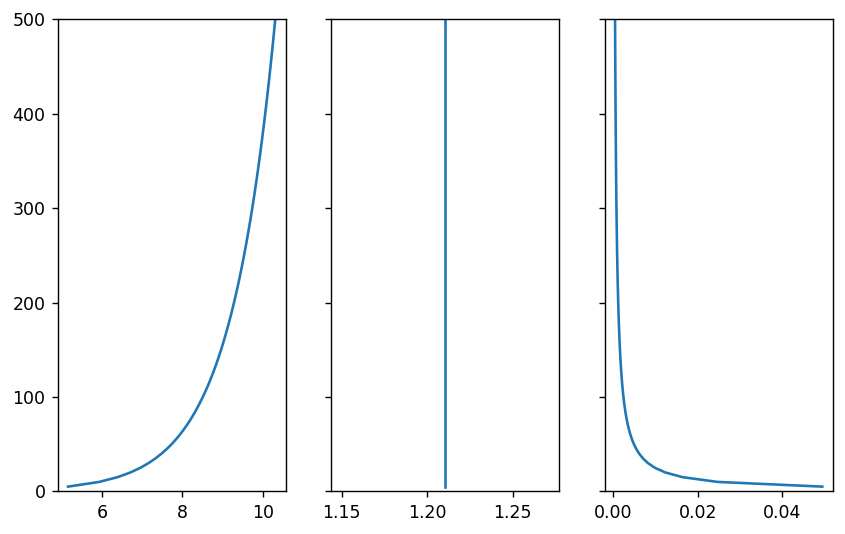

In [8]:
fig, axs = plt.subplots(1,3, sharey=True, dpi=125, figsize=(8,5))
axs[0].plot(Uinit[Ny//2,:], zvec)
axs[1].plot(Kinit[Ny//2,:], zvec)
axs[2].plot(EPSinit[Ny//2,:], zvec)
axs[0].set_ylim([0, zmax])

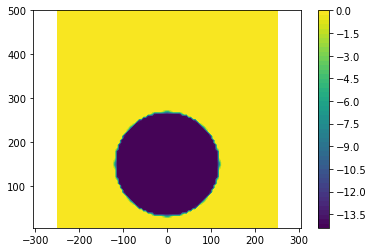

In [9]:
# Plot what the wake forcing field looks like
Uinf = sdb.rotorAvgUh(ym, zm, Uinit, Vinit, params['turbforcing']['turby'], params['turbforcing']['zhh'], 0.5*params['turbforcing']['turbD'])
wakeF = sdb.tanhADM(1.0, ym, zm,  5.98, params['turbforcing'])
plt.contourf(ym, zm, wakeF, levels=51)
plt.axis('equal')
plt.colorbar()

In [10]:
# Testing to see if Uinf / Ct lookup table works
sdb.CtTableLookup(Uinf, params['turbforcing'])

0.778275899

In [11]:
D = params['turbforcing']['turbD']
xvecplot=np.array([-1,0,1,2,3,4])*D
dx  = 0.5*D #25

#xvec = [0, 10, 20, 30, 40]
xvec = np.arange(xvecplot[0], xvecplot[-1]+1.0E-6, dx)
#xvec = [0, 10, 20]

#xvec = [0.0, 2.5, 5.0, 7.5, 10, 15, 20, 25, 30]
#xvec = np.arange(xvecplot[0], xvecplot[0]+dx+1.0E-6, dx)

#xvec = xvecplot
start_time = time.time()
phi = SANDwake3D.marchSystem(phiinit, xvec, dy, dz, params, 
                             SANDwake3D.getTypicalWMBC(Uinit[0,-1], params['Tw'], veerBC=veerV),
                             SANDwake3D.kepsT_eqns, 
                             advanceSys=SANDwake3D.advanceSystemKEPS,
                             verbose=True, maxiter=100, tol=1.0E-4)
end_time = time.time()
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.4f} seconds")

x = -120.0 dx = 120.0
[0] u: 9.0061e+00, w: 0.0000e+00, k: 3.7462e+00, eps: 2.1274e-01, T: 1.7755e-11, v: 0.0000e+00, p: 0.0000e+00
[1] u: 5.7662e+00, w: 0.0000e+00, k: 3.4132e+00, eps: 1.6207e-01, T: 2.6414e-11, v: 0.0000e+00, p: 2.9018e-04
[2] u: 3.3886e+00, w: 1.5049e-04, k: 2.8776e+00, eps: 1.2600e-01, T: 2.9788e-11, v: 1.3903e-05, p: 2.5602e-04
[3] u: 2.0149e+00, w: 1.2733e-04, k: 1.8901e+00, eps: 7.8596e-02, T: 3.2639e-11, v: 1.4382e-05, p: 2.2295e-04
[4] u: 1.0709e+00, w: 1.1495e-04, k: 1.1335e+00, eps: 4.4871e-02, T: 3.0488e-11, v: 1.1427e-05, p: 1.4078e-04
[5] u: 5.6914e-01, w: 7.2256e-05, k: 6.0546e-01, eps: 2.3832e-02, T: 2.7318e-11, v: 7.1340e-06, p: 8.4088e-05
[6] u: 2.8534e-01, w: 4.3063e-05, k: 3.1904e-01, eps: 1.2327e-02, T: 2.5502e-11, v: 4.2684e-06, p: 4.2894e-05
[7] u: 1.4443e-01, w: 2.1889e-05, k: 1.6131e-01, eps: 6.2252e-03, T: 2.6554e-11, v: 2.1829e-06, p: 2.2631e-05
[8] u: 7.1708e-02, w: 1.1566e-05, k: 8.1299e-02, eps: 3.1198e-03, T: 2.6836e-11, v: 1.1496e-06, p:

(5.0, 500.0)

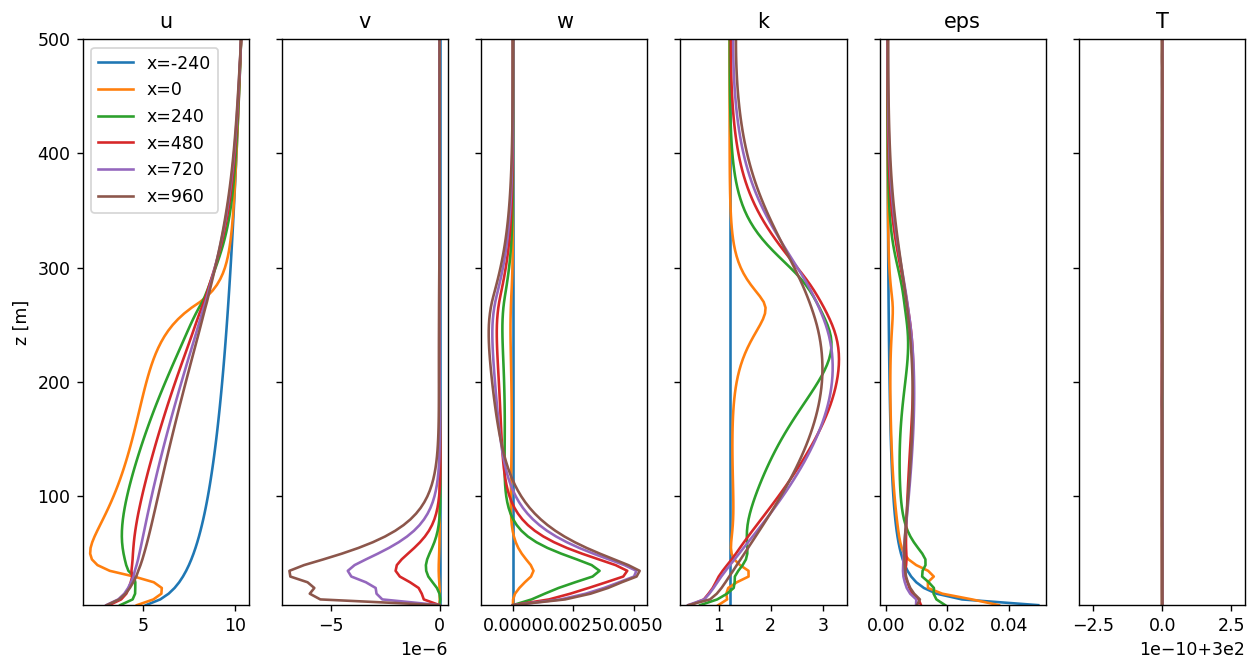

In [12]:
plotvars=['u', 'v', 'w', 'k', 'eps', 'T']
find_nearest = lambda a, a0: np.abs(np.array(a) - a0).argmin()
islice = find_nearest(yvec, 0)# Ny//2

#xvecplot=[0, 50]

fig, axs = plt.subplots(1,len(plotvars),figsize=(12,6), dpi=125, sharey=True)
for iv, v in enumerate(plotvars):
    for x in xvecplot:
        ixRANS = find_nearest(xvec, x)
        axs[iv].plot(phi[v][ixRANS,islice,:], zvec, label='x=%.0f'%x)
    axs[iv].set_title(v)
    
axs[0].legend()
#axs[0].set_xlim([0, 9])
axs[0].set_ylabel('z [m]')
axs[0].set_ylim([zmin, zmax])

Text(0, 0.5, 'y')

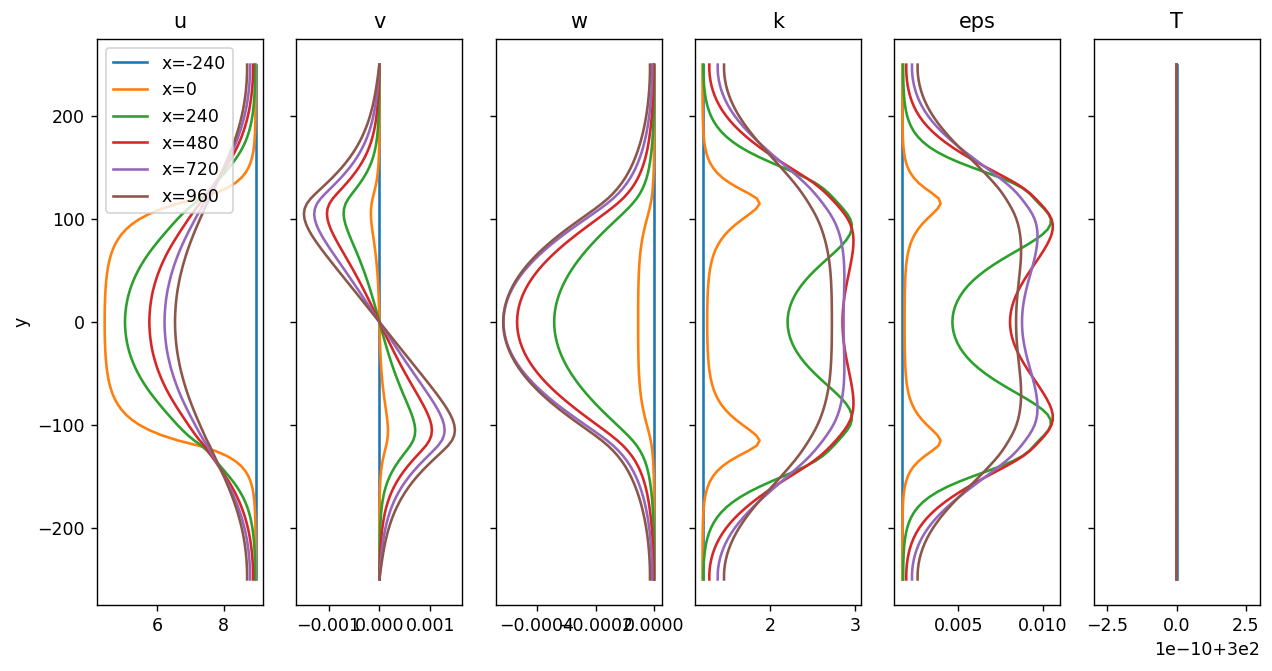

In [13]:
plotvars=['u', 'v', 'w', 'k', 'eps', 'T']
islice = find_nearest(zvec, params['turbforcing']['zhh'])# Ny//2

#xvecplot=[0, 50]

fig, axs = plt.subplots(1,len(plotvars),figsize=(12,6), dpi=125, sharey=True)
for iv, v in enumerate(plotvars):
    for x in xvecplot:
        ixRANS = find_nearest(xvec, x)
        axs[iv].plot(phi[v][ixRANS,:,islice], yvec, label='x=%.0f'%x)
    axs[iv].set_title(v)
    
axs[0].legend()
#axs[0].set_xlim([0, 9])
axs[0].set_ylabel('y')
#axs[0].set_ylim([zmin, zmax])

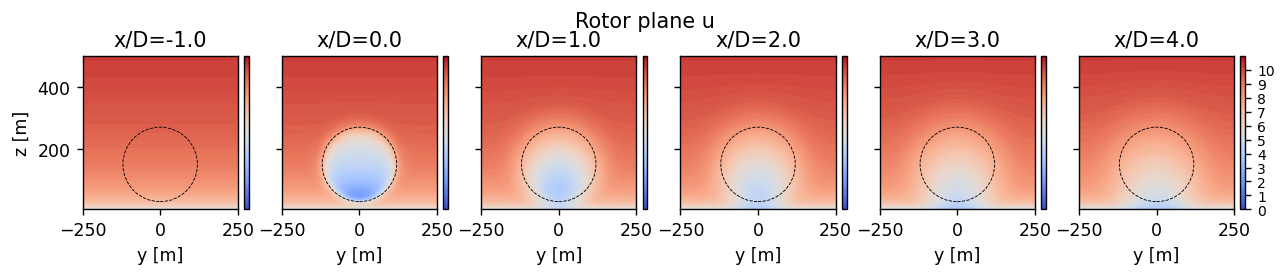

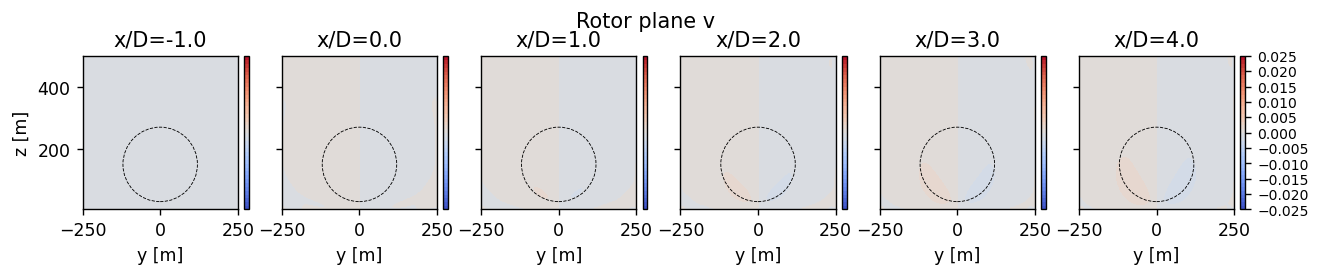

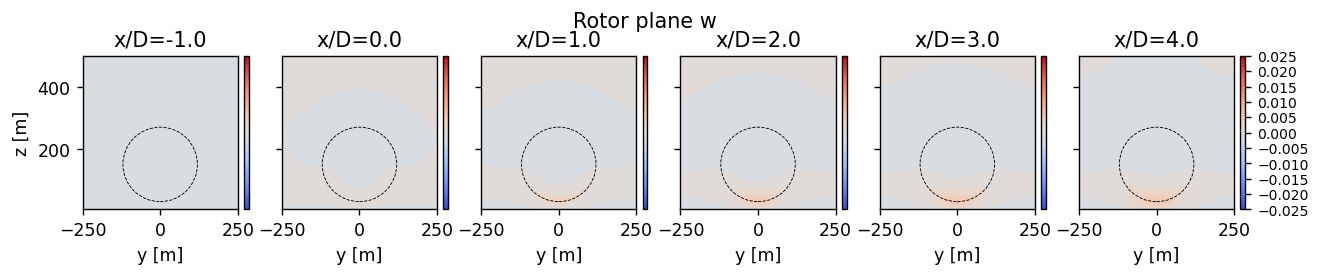

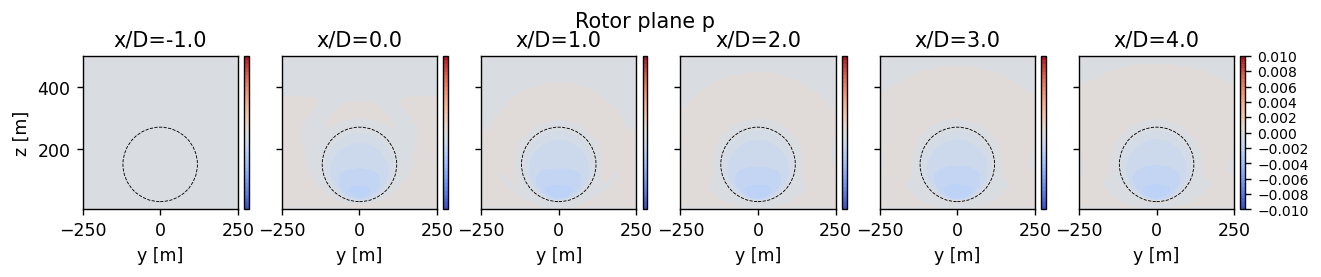

In [14]:
savefigs = False
cbarticks=np.arange(0,11,1)
plotvars=['u','v', 'w', 'p']
maxL=0.025
maxP=0.01
vlevels={'u':{'levels':np.linspace(0,11,91), 'cbarticks':np.arange(0,11,1)},
         'v':{'levels':np.linspace(-maxL,maxL,41), 'cbarticks':np.arange(-maxL, maxL+1E-5,maxL/5)},
         'w':{'levels':np.linspace(-maxL,maxL,41), 'cbarticks':np.arange(-maxL, maxL+1E-5,maxL/5)}, 
         'p':{'levels':np.linspace(-maxP,maxP,41), 'cbarticks':np.arange(-maxP, maxP+1E-5,maxP/5)}, 
        }

for plotv in plotvars:
    fig, axs = plt.subplots(1, len(xvecplot), figsize=(12,3.25), dpi=125, sharey=True)
    for ix, x in enumerate(xvecplot):
        ixRANS = find_nearest(xvec, x)
        c=axs[ix].contourf(ym, zm, phi[plotv][ixRANS,:,:], levels=vlevels[plotv]['levels'], cmap='coolwarm')
        axs[ix].set_aspect('equal')
        axs[ix].set_title('x/D=%.1f'%(0.5*x/turbR))
        axs[ix].set_xlabel('y [m]')
        rotorcirc = plt.Circle((0.0, turbhh), turbR, color='k', linestyle='--', lw=0.5, fill=False)
        axs[ix].add_patch(rotorcirc)
    
        divider = make_axes_locatable(axs[ix])
        cax = divider.append_axes("right", size="3%", pad=0.05)
        if ix < len(xvecplot)-1:
            cbar=fig.colorbar(c, ax=axs[ix], cax=cax, ticks = matplotlib.ticker.FixedLocator([]))
        else:
            cbar=fig.colorbar(c, ax=axs[ix], cax=cax, ticks = matplotlib.ticker.FixedLocator(vlevels[plotv]['cbarticks']))
            cbar.ax.tick_params(labelsize=8)
        
    axs[0].set_ylabel('z [m]')
    plt.suptitle('Rotor plane '+plotv,y=0.8)

if savefigs:
    plt.tight_layout()
    plt.savefig('TestABL_KEPST.png')